---
jupytext:
  text_representation:
    format_name: myst
kernelspec:
  display_name: Python 3
  language: python
  name: python3
---

# 5. 螺旋线大全 Spirals

螺旋线是极坐标中 $r$ 随 $\theta$ 变化的曲线。包含了从阿基米德到现代的各类螺旋。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, exp, atan
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

## 5.1 阿基米德螺旋 Archimedean Spiral

$r = a\theta$

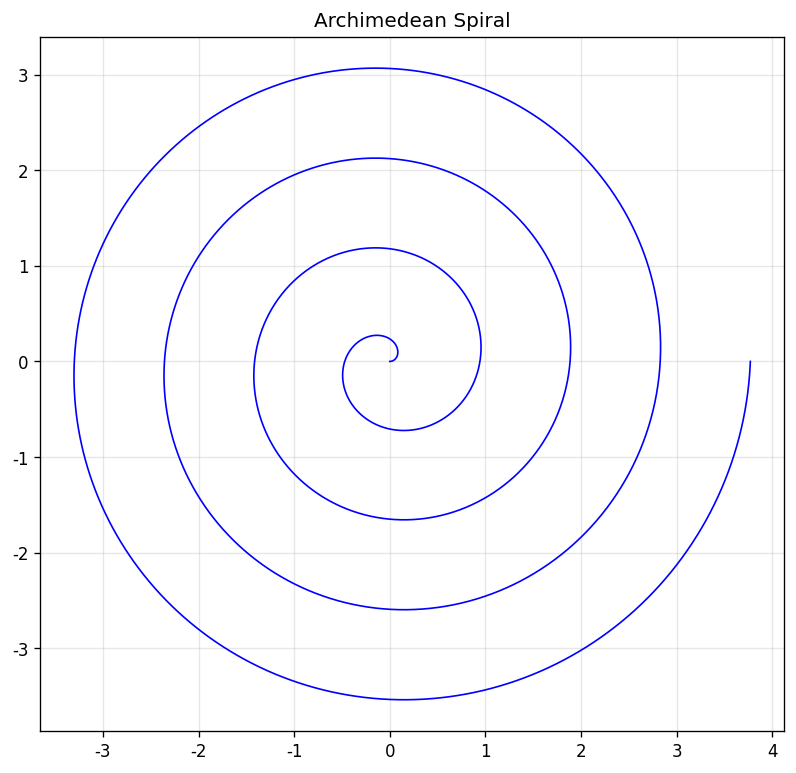

In [2]:
theta = np.linspace(0, 8*np.pi, 4000)
a = 0.15
r = a * theta
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'b-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Archimedean Spiral') # / 阿基米德螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.2 对数螺旋 Logarithmic Spiral

$r = ae^{b\theta}$

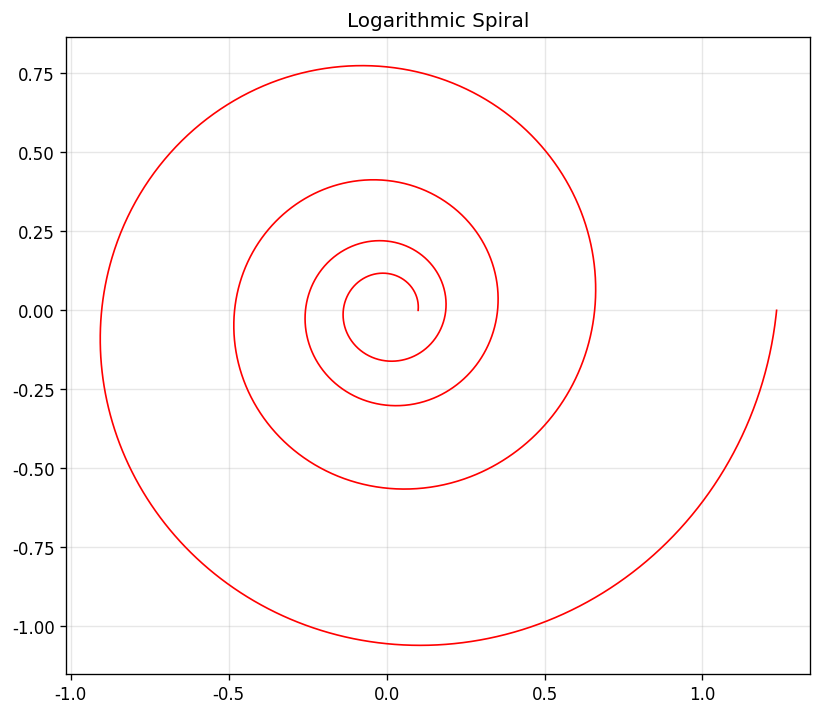

In [3]:
theta = np.linspace(0, 8*np.pi, 4000)
a, b = 0.1, 0.1
r = a * np.exp(b * theta)
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'r-', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Logarithmic Spiral') # / 对数螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.3 费马螺旋 Fermat's Spiral

$r^2 = a^2\theta$

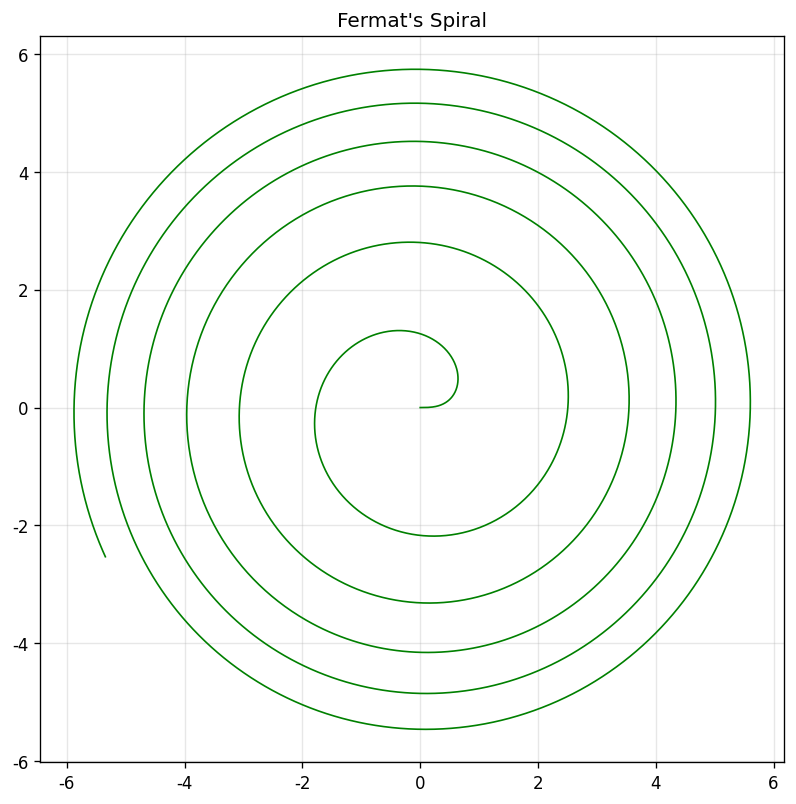

In [4]:
theta = np.linspace(0, 35, 4000)
a = 1
r = a * np.sqrt(theta)
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'g-', linewidth=1)
ax.set_aspect('equal')
ax.set_title("Fermat's Spiral") # / 费马螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.4 双曲螺旋 Hyperbolic Spiral

$r = a/\theta$

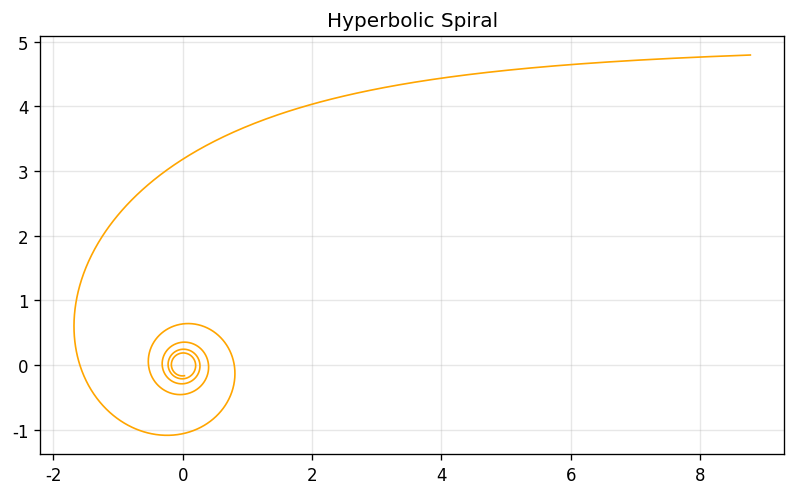

In [5]:
theta = np.linspace(0.5, 30, 4000)
a = 5
r = a / theta
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'orange', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Hyperbolic Spiral') # / 双曲螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.5 连锁螺线 / 利图螺旋 Lituus

$r^2\theta = a^2$

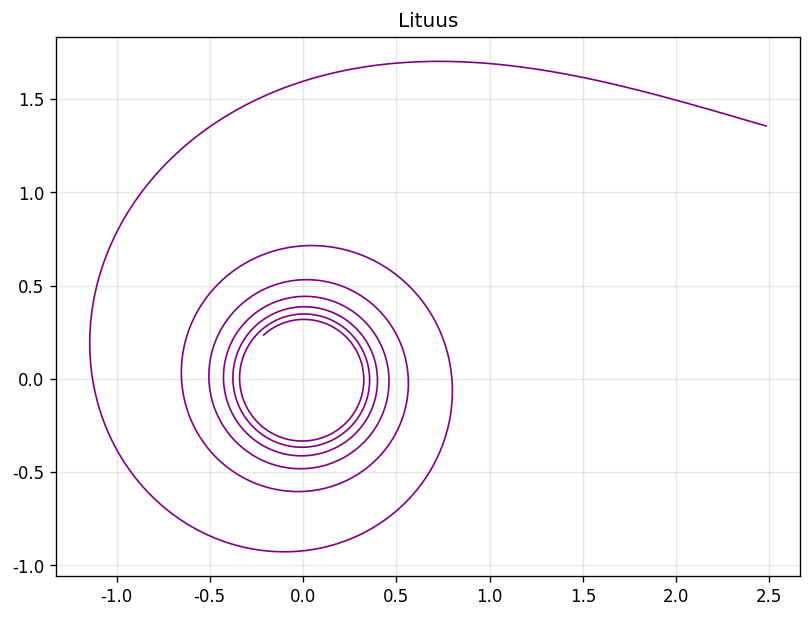

In [6]:
theta = np.linspace(0.5, 40, 4000)
a = 2
r = a / np.sqrt(theta)
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'purple', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Lituus') # / 连锁螺线
ax.grid(True, alpha=0.3)
plt.show()

## 5.6 欧拉螺旋 / 羊角螺线 Euler Spiral / Clothoid

Fresnel 积分：$x = \int \cos(t^2)dt, \quad y = \int \sin(t^2)dt$

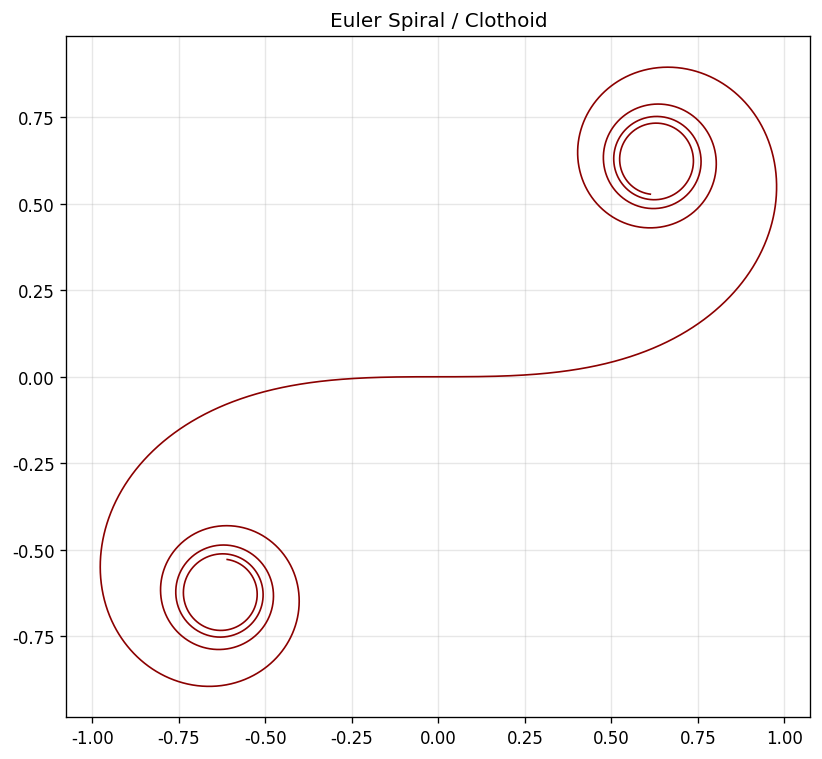

In [7]:
t = np.linspace(-5, 5, 5000)
du = np.gradient(t)
x = np.cumsum(np.cos(t**2) * du)
y = np.cumsum(np.sin(t**2) * du)
x, y = x - x.mean(), y - y.mean()
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'darkred', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Euler Spiral / Clothoid')
ax.grid(True, alpha=0.3)
plt.show()

## 5.7 科努螺旋 Cornu Spiral

Fresnel 积分的另一种形式。

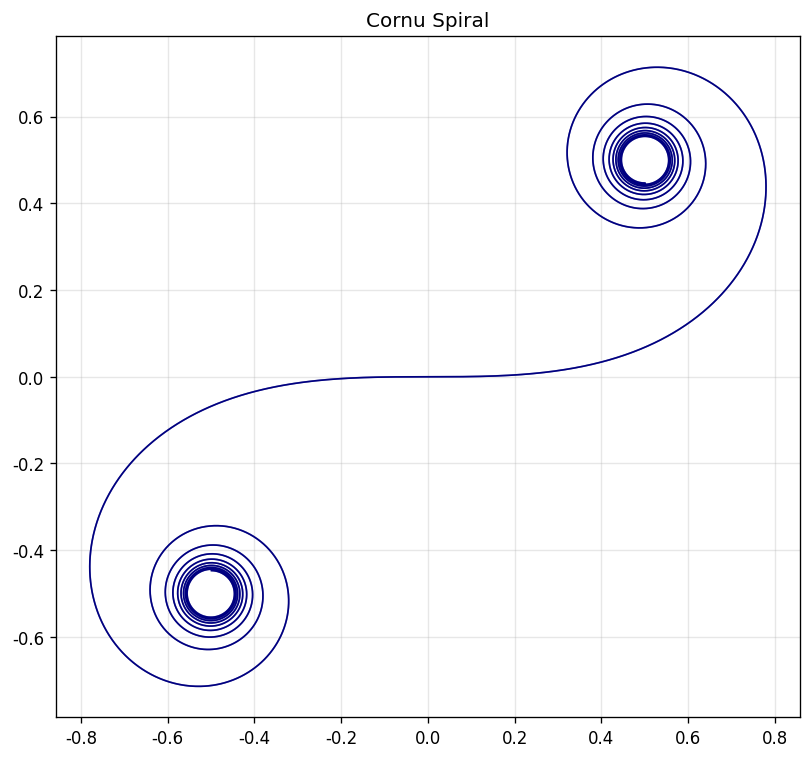

In [8]:
t = np.linspace(-6, 6, 5000)
du = np.gradient(t)
x = np.cumsum(np.cos(np.pi * t**2 / 2) * du)
y = np.cumsum(np.sin(np.pi * t**2 / 2) * du)
x, y = x - x.mean(), y - y.mean()
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'navy', linewidth=1)
ax.plot(-x, -y, 'navy', linewidth=1, alpha=0.5)
ax.set_aspect('equal')
ax.set_title('Cornu Spiral') # / 科努螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.8 西奥多罗斯螺旋 Spiral of Theodorus

直角三角形构造的螺旋。

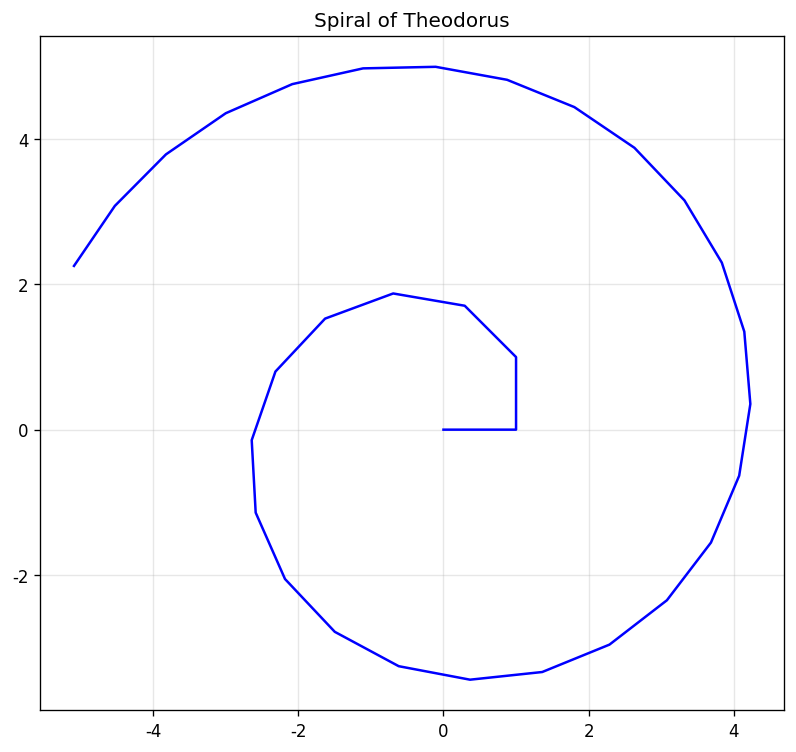

In [9]:
n = 30
x_pts, y_pts = [0.0, 1.0], [0.0, 0.0]
angle = 0.0
for k in range(1, n+1):
    angle += np.arctan(1/np.sqrt(k))
    radius = np.sqrt(k + 1)
    x_pts.append(radius * np.cos(angle))
    y_pts.append(radius * np.sin(angle))
x_pts, y_pts = np.array(x_pts), np.array(y_pts)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x_pts, y_pts, 'b-', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title('Spiral of Theodorus') # / 西奥多罗斯螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.9 斐波那契螺旋 Fibonacci Spiral

金矩形中的四分之一圆弧。

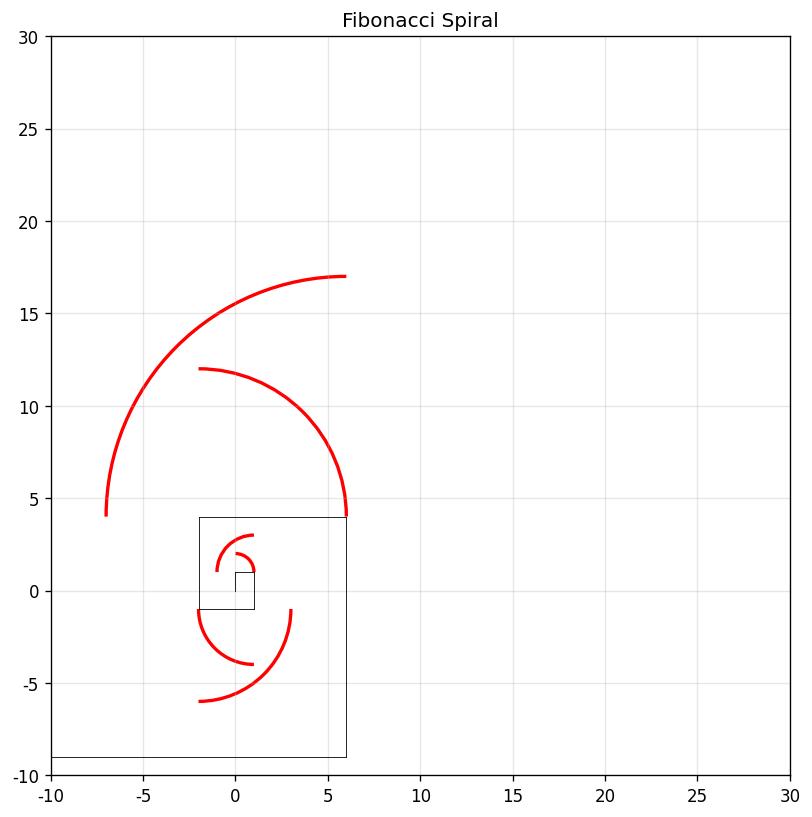

In [10]:
fig, ax = plt.subplots(figsize=(8,8))
x, y = 0, 0
dx, dy = 1, 1
fib = [1, 1, 2, 3, 5, 8, 13, 21]
directions = [(0,1), (1,0), (0,-1), (-1,0)]
angles = [(0,90), (90,180), (180,270), (270,360)]
from matplotlib.patches import Arc
for i, f in enumerate(fib):
    d = directions[i % 4]
    nx, ny = x + d[0]*f, y + d[1]*f
    ax.plot(*zip(*[(x,y),(nx,ny)]), 'k-', linewidth=0.5)
    if i < len(fib)-1:
        theta = angles[i % 4]
        arc = Arc((nx, ny), 2*fib[i+1], 2*fib[i+1], angle=0, theta1=theta[0], theta2=theta[1], color='red', linewidth=2)
        ax.add_patch(arc)
    x, y = nx, ny
ax.set_aspect('equal')
ax.set_title('Fibonacci Spiral') # / 斐波那契螺旋
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30); ax.set_ylim(-10, 30)
plt.show()

## 5.10 黄金螺旋 Golden Spiral

$r = \phi^{2\theta/\pi}$

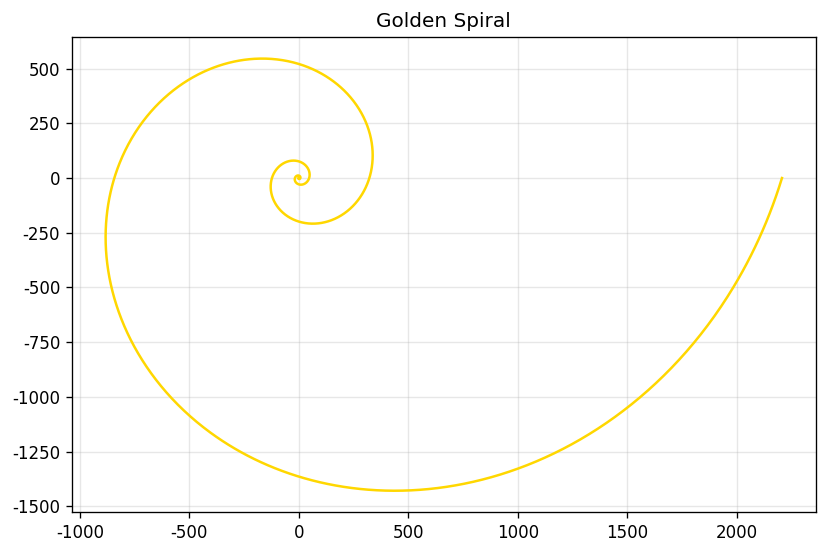

In [11]:
theta = np.linspace(0, 8*np.pi, 4000)
phi = (1 + np.sqrt(5)) / 2
r = phi ** (2*theta/np.pi)
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'gold', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title('Golden Spiral') # / 黄金螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.11 伽利略螺旋 Galilean Spiral

$r = a\theta^2$

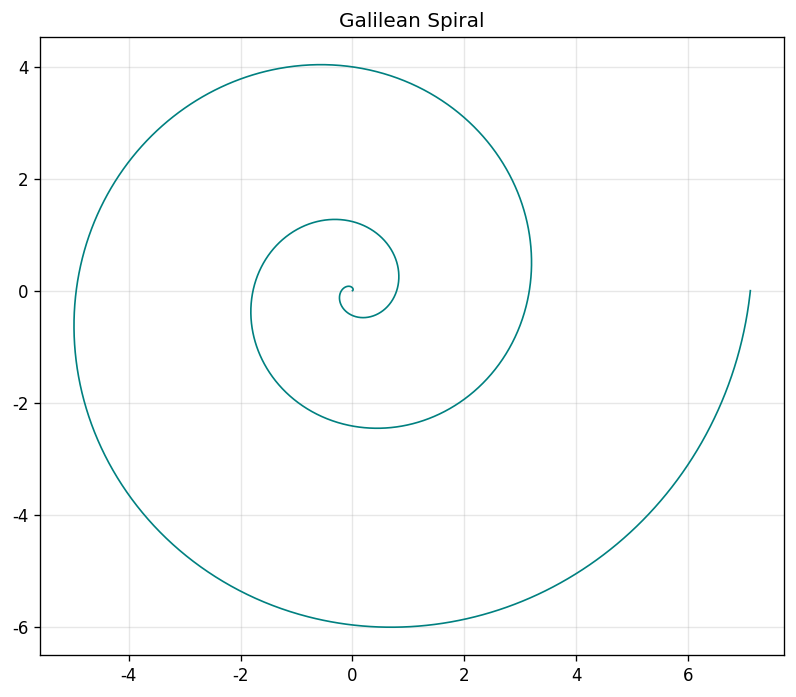

In [12]:
theta = np.linspace(0, 6*np.pi, 4000)
a = 0.02
r = a * theta**2
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'teal', linewidth=1)
ax.set_aspect('equal')
ax.set_title('Galilean Spiral') # / 伽利略螺旋
ax.grid(True, alpha=0.3)
plt.show()

## 5.12 尼尔森螺旋 Nielsen's Spiral

$r = a\sqrt{\theta}$ — 变体费马螺旋

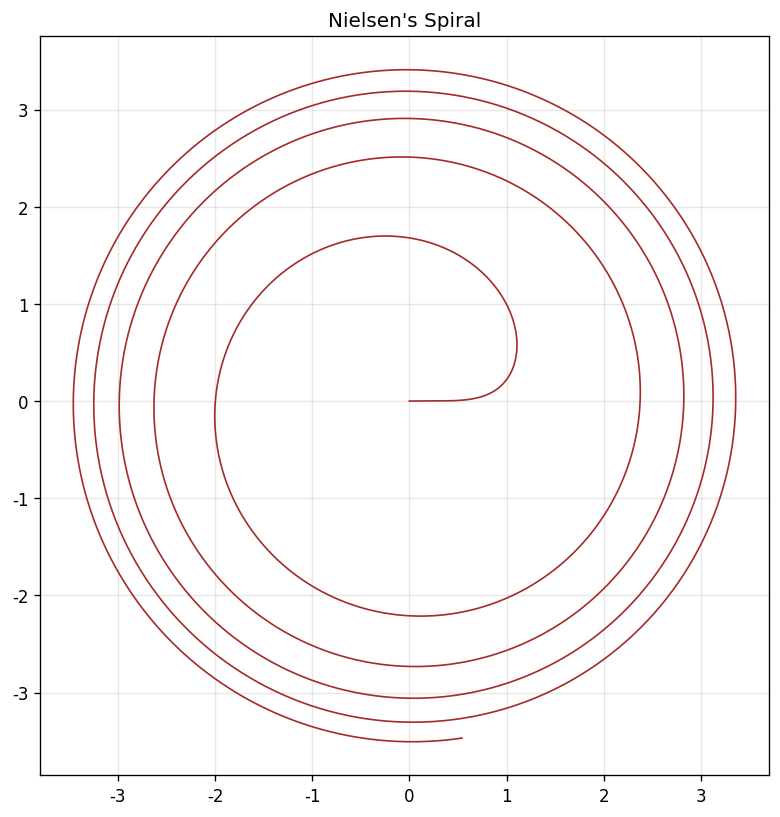

In [13]:
theta = np.linspace(0, 30, 4000)
a = 1.5
r = a * theta**0.25
x, y = r*np.cos(theta), r*np.sin(theta)
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(x, y, 'brown', linewidth=1)
ax.set_aspect('equal')
ax.set_title("Nielsen's Spiral") # / 尼尔森螺旋
ax.grid(True, alpha=0.3)
plt.show()